In [1]:
import torch
import torch.nn as nn
import dataloader as dl
import torch.optim as SGD
import numpy as np
from sklearn.metrics import confusion_matrix
import time

num_of_epochs = 15



# Best Logistic Regression Model

### Class Definition


In [2]:
torch.manual_seed(42)

class Logistic_Regression_from_scratch():
    def __init__(self):
        self.w = torch.randn(28*28, requires_grad=True)
        
        self.b = torch.zeros(1, requires_grad=True)
        
        self.validation_losses = []
        self.training_losses = []
        self.validation_accuracies = []
        self.training_accuracies = []
        
    def sigmoid(self, z):
        return 1 / (1 + torch.exp(-z))

    def bce_loss(self,y_true, y_pred):
        epsilon = 1e-7
        loss = - (y_true * torch.log(y_pred + epsilon) + (1 - y_true) * torch.log(1 - y_pred + epsilon))
        return torch.mean(loss)
    
    def forward_pass(self, x):
        output =  x @ self.w + self.b
        y_pred = self.sigmoid(output)
        return y_pred
    
    def train(self, learning_rate, no_epochs, train_loader, val_loader):
        for epoch in range(no_epochs):
            train_loss = 0
            val_losses = 0
            train_accuracy = 0
            val_accuracy = 0
            
            for data, target in train_loader:
                target = target.float()
                
                y_pred = self.forward_pass(data)
                loss = self.bce_loss(target, y_pred)
                

                train_accuracy += self.calculate_accuracy(target, y_pred)

                train_loss += loss.item()
                
                loss.backward()
                
                with torch.no_grad():
                    self.w -= learning_rate * self.w.grad
                    self.b  -= learning_rate * self.b.grad
                    
                    self.w.grad.zero_()
                    self.b.grad.zero_()

            
            
            with torch.no_grad():
                for val_data, val_target in val_loader:
                    val_target = val_target.float()
                    val_pred = self.forward_pass(val_data)
                    
                    val_accuracy += self.calculate_accuracy(val_target, val_pred)
                    
                    val_loss = self.bce_loss(val_target, val_pred)
                    val_losses += val_loss.item()
                    
                    
            self.training_accuracies.append(train_accuracy / len(train_loader))
            self.validation_accuracies.append(val_accuracy / len(val_loader))
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_losses / len(val_loader)

            
            self.training_losses.append(avg_train_loss)
            self.validation_losses.append(avg_val_loss)
            
            print(f'Epoch {epoch+1}/{no_epochs}')
            print(f'  Train Loss: {avg_train_loss:.4f} | Train Acc: {self.training_accuracies[epoch]:.2f}%')
            print(f'  Val Loss: {avg_val_loss:.4f} | Val Acc: {self.validation_accuracies[epoch]:.2f}%')
            


    def predict(self, x):
        with torch.no_grad():
            y_pred = self.forward_pass(x)
            predicted_labels = (y_pred > 0.5).float()
        return predicted_labels

    def calculate_accuracy(self, y_true, y_pred):
        predicted_labels = (y_pred > 0.5).float()
        return (predicted_labels == y_true).sum().item() / y_true.shape[0] *100

### Training the Model with the best Hyperparameters 

In [3]:
learning_rate = 1
batch_size = 16


Logistic_Regression_model = Logistic_Regression_from_scratch()
loader = dl.build_loader(batch_size)
train_loader, val_loader, test_loader = loader['train_loader_linear_filtered'], loader['val_loader_linear_filtered'], loader['test_loader_linear_filtered']

start_time = time.time()
Logistic_Regression_model.train(learning_rate, num_of_epochs, train_loader, val_loader)
end_time = time.time()

Logistic_Regression_time = end_time - start_time
print(f"Training Time: {Logistic_Regression_time:.2f} seconds")

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 3538088.00it/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 208463.24it/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 1610687.95it/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 2282047.05it/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/15
  Train Loss: 0.0273 | Train Acc: 99.45%
  Val Loss: 0.0181 | Val Acc: 99.65%
Epoch 2/15
  Train Loss: 0.0073 | Train Acc: 99.84%
  Val L

# Best Softmax Model

### Class Definition

In [4]:
class Softmax_Regression_from_scratch():
    def __init__(self, input_size, num_classes):
        self.w = nn.Parameter(torch.randn(input_size, num_classes) * 0.01, requires_grad=True)
        self.b = torch.zeros(num_classes, requires_grad=True)
        
        
        
        self.validation_losses = []
        self.training_losses = []
        self.validation_accuracies = []
        self.training_accuracies = []
        
    def softmax(self, z):
        exp_z = torch.exp(z)
        return exp_z / torch.sum(exp_z, dim=1, keepdim=True)
    
    def cross_entropy_loss(self, y_true_indices, y_pred_softmax):
        num_samples = y_true_indices.shape[0]
        correct_class_probs = y_pred_softmax[range(num_samples), y_true_indices]
        epsilon = 1e-9
        loss = -torch.log(correct_class_probs + epsilon)
        return torch.mean(loss)
    
    def forward_pass(self, x):
        logits = x @ self.w + self.b
        y_pred_softmax = self.softmax(logits)
        return y_pred_softmax
    
    
    def train(self, learning_rate, no_epochs, train_loader, val_loader):        
        ## training phase
        for epoch in range(no_epochs):
            train_loss = 0
            val_losses = 0
            train_accuracy = 0
            val_accuracy = 0
            for data, target in train_loader:
                
                y_pred = self.forward_pass(data)
                loss = self.cross_entropy_loss(target, y_pred)
                
                train_accuracy += self.calculate_accuracy(target, y_pred)
                train_loss += loss.item()
                
                loss.backward()
                
                with torch.no_grad():
                    self.w -= learning_rate * self.w.grad
                    self.b -= learning_rate * self.b.grad
                    
                    self.w.grad.zero_()
                    self.b.grad.zero_()
                    
            ## Validation Phase        
            with torch.no_grad():
                for val_data, val_target in val_loader:
                    val_pred = self.forward_pass(val_data)
                    
                    val_accuracy += self.calculate_accuracy(val_target, val_pred)
                    val_loss = self.cross_entropy_loss(val_target, val_pred)
                    
                    val_losses += val_loss.item()
                    
            self.training_accuracies.append(train_accuracy / len(train_loader))
            self.validation_accuracies.append(val_accuracy / len(val_loader))
            
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_losses / len(val_loader)
            
            self.training_losses.append(avg_train_loss)
            self.validation_losses.append(avg_val_loss)
            
            print(f'Epoch {epoch+1}/{no_epochs}')
            print(f'  Train Loss: {avg_train_loss:.4f} | Train Acc: {self.training_accuracies[epoch]:.2f}%')
            print(f'  Val Loss: {avg_val_loss:.4f}   | Val Acc: {self.validation_accuracies[epoch]:.2f}%')
        
    def predict(self, x):
        with torch.no_grad():
            y_pred = self.forward_pass(x)
            predicted_labels = torch.argmax(y_pred, dim=1)
        return predicted_labels
    
    def calculate_accuracy(self, y_true_indices, y_pred_softmax):
        predicted_labels = torch.argmax(y_pred_softmax, dim=1)
        correct = (predicted_labels == y_true_indices).sum().item()
        return (correct / y_true_indices.shape[0]) * 100

### Training the Model with the best Hyperparameters 

In [5]:
learning_rate = 0.1
batch_size = 16

Softmax_Regression_model = Softmax_Regression_from_scratch(input_size=28*28, num_classes=10)
loader = dl.build_loader(batch_size)
train_loader, val_loader, test_loader = loader['train_loader_linear'], loader['val_loader_linear'], loader['test_loader_linear']

start_time = time.time()
Softmax_Regression_model.train(learning_rate, num_of_epochs, train_loader, val_loader)
end_time = time.time()
Softmax_Regression_time = end_time - start_time

print(f"Training Time: {Softmax_Regression_time:.2f} seconds")

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])
Epoch 1/15
  Train Loss: 0.4076 | Train Acc: 88.36%
  Val Loss: 0.3293   | Val Acc: 90.58%
Epoch 2/15
  Train Loss: 0.3118 | Train Acc: 91.09%
  Val Loss: 0.3022   | Val Acc: 91.24%
Epoch 3/15
  Train Loss: 0.2943 | Train A

# Best Neural Network Model

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Class Definition

In [7]:
batch_size = 16
learning_rate = 0.1

def create_nn_model(num_hidden_layers, neurons_per_layer):
    layers = []
    layers.append(nn.Linear(28 * 28, neurons_per_layer))

    for _ in range(num_hidden_layers):
        layers.append(nn.ReLU())
        layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))

    layers.append(nn.ReLU())
    layers.append(nn.Linear(neurons_per_layer, 10))

    return nn.Sequential(*layers)


neural_network = create_nn_model(num_hidden_layers=5, neurons_per_layer=512)

train_losses = []
val_losses = []
train_accs = []
val_accs = []
test_acc_list = []
neural_network.to(device)


loss_function = nn.CrossEntropyLoss()
optimizer = SGD.SGD(neural_network.parameters(), lr=learning_rate)
loader=dl.build_loader(batch_size)

train_loader = loader['train_loader_linear']
val_loader = loader['val_loader_linear']
test_loader = loader['test_loader_linear']

Number of training samples: 60000
Shape of x_train: torch.Size([36000, 28, 28]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 28, 28]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 28, 28]), y_test: torch.Size([12000])
After filtering for classes 0 and 1:
Shape of x_train_filtered: torch.Size([7599, 784]), y_train_filtered: torch.Size([7599])
Shape of x_val_filtered: torch.Size([2532, 784]), y_val_filtered: torch.Size([2532])
Shape of x_test_filtered: torch.Size([2534, 784]), y_test_filtered: torch.Size([2534])
---------
Shape of x_train: torch.Size([36000, 784]), y_train: torch.Size([36000])
Shape of x_val: torch.Size([12000, 784]), y_val: torch.Size([12000])
Shape of x_test: torch.Size([12000, 784]), y_test: torch.Size([12000])


### Training the Model with the best Hyperparameters

In [9]:

start_time = time.time()

for epoch in range(num_of_epochs):
        # TRAINING
        train_loss = 0
        train_correct = 0
        train_total = 0

        for data, target in loader['train_loader_linear']:
            data = data.to(device)
            target = target.to(device)

            optimizer.zero_grad()
            output = neural_network(data)
            loss = loss_function(output, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(output, 1)
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()

        # VALIDATION
        neural_network.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in loader['val_loader_linear']:
                data = data.to(device)
                target = target.to(device)

                output = neural_network(data)
                loss = loss_function(output, target)

                val_loss += loss.item()
                _, predicted = torch.max(output, 1)
                val_total += target.size(0)
                val_correct += (predicted == target).sum().item()

        # Calculate averages
        train_loss = train_loss / len(loader['train_loader_nn'])
        val_loss = val_loss / len(loader['val_loader_nn'])
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Print progress
        print(f'Epoch {epoch+1}/{num_of_epochs}')
        print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
        print(f'  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
        
end_time = time.time()

Neural_Network_time = end_time - start_time
print(f"Training Time: {Neural_Network_time:.2f} seconds")


Epoch 1/15
  Train Loss: 0.1727 | Train Acc: 95.05%
  Val Loss: 0.1402 | Val Acc: 96.08%
Epoch 2/15
  Train Loss: 0.1127 | Train Acc: 96.87%
  Val Loss: 0.1383 | Val Acc: 96.11%
Epoch 3/15
  Train Loss: 0.0866 | Train Acc: 97.47%
  Val Loss: 0.1110 | Val Acc: 96.88%
Epoch 4/15
  Train Loss: 0.0666 | Train Acc: 98.14%
  Val Loss: 0.1231 | Val Acc: 96.83%
Epoch 5/15
  Train Loss: 0.0570 | Train Acc: 98.33%
  Val Loss: 0.1064 | Val Acc: 97.13%
Epoch 6/15
  Train Loss: 0.0429 | Train Acc: 98.74%
  Val Loss: 0.1096 | Val Acc: 97.16%
Epoch 7/15
  Train Loss: 0.0360 | Train Acc: 98.96%
  Val Loss: 0.1249 | Val Acc: 97.08%
Epoch 8/15
  Train Loss: 0.0296 | Train Acc: 99.13%
  Val Loss: 0.1080 | Val Acc: 97.38%
Epoch 9/15
  Train Loss: 0.0244 | Train Acc: 99.26%
  Val Loss: 0.1225 | Val Acc: 97.22%
Epoch 10/15
  Train Loss: 0.0240 | Train Acc: 99.31%
  Val Loss: 0.1222 | Val Acc: 97.46%
Epoch 11/15
  Train Loss: 0.0217 | Train Acc: 99.35%
  Val Loss: 0.1213 | Val Acc: 97.19%
Epoch 12/15
  Train

# Running each model on the test set and comparing their performance

## Logistsic Regression Test Performance

In [13]:

accuracy = 0
targets = []
predictions = []
start_time = time.time()
with torch.no_grad(): 
    for data, target in loader['test_loader_linear_filtered']:
        target = target.float()
        
        prediction = Logistic_Regression_model.predict(data)
        accuracy += Logistic_Regression_model.calculate_accuracy(target, prediction)
        targets.extend(target.numpy())
        predictions.extend(prediction)
test_accuracy = accuracy / len(loader['test_loader_linear_filtered'])

end_time = time.time()
Logistic_Regression_test_time = end_time - start_time


print(f'Average Test Accuracy over all batches: {test_accuracy:.2f}%')
print(f"Testing Time: {Logistic_Regression_test_time:.2f} seconds")

confusion_matrix_Logistic = confusion_matrix(np.array(targets),np.array(predictions))


Average Test Accuracy over all batches: 99.84%
Testing Time: 0.07 seconds


## Softmax Regression Test Performance

In [14]:
accuracy = 0
all_targets = []
all_predictions = []
start_time = time.time()
with torch.no_grad(): 
    for data, target in loader['test_loader_linear']:
        prediction = Softmax_Regression_model.predict(data) 
        correct = (prediction == target).sum().item()
        total = target.shape[0]
        accuracy += (correct / total) * 100
        all_targets.extend(target.numpy())
        all_predictions.extend(prediction.numpy())
        
end_time = time.time()
        
test_accuracy = accuracy / len(loader['test_loader_linear'])
print(f'Average Test Accuracy over all batches: {test_accuracy:.2f}%')

Softmax_Regression_test_time = end_time - start_time
print(f"Testing Time: {Softmax_Regression_test_time:.2f} seconds")

confusion_matrix_softmax = confusion_matrix(np.array(all_targets), np.array(all_predictions))


Average Test Accuracy over all batches: 91.70%
Testing Time: 0.18 seconds


## Neural Network Test Performance

In [25]:
import time
from sklearn.metrics import confusion_matrix

test_acc_list = []
all_preds = []
all_targets = []

start_time = time.time()

for data, target in loader['test_loader_linear']:
    data = data.to(device)
    target = target.to(device)

    output = neural_network(data)
    _, predicted = torch.max(output, 1)

    test_total = target.size(0)
    test_correct = (predicted == target).sum().item()

    test_acc = 100 * test_correct / test_total
    test_acc_list.append(test_acc)

    # Collect for confusion matrix
    all_preds.extend(predicted.cpu().numpy())
    all_targets.extend(target.cpu().numpy())

end_time = time.time()

average_test_acc = sum(test_acc_list) / len(test_acc_list)
Neural_Network_time_test = end_time - start_time

print(f'Average Test Accuracy over all batches: {average_test_acc:.2f}%')
print(f'Testing Time: {Neural_Network_time_test:.2f} seconds')

confusion_matrix_Neural_Network = confusion_matrix(all_targets, all_preds)


Average Test Accuracy over all batches: 97.40%
Testing Time: 3.10 seconds


# Time Comparison Between Models


| Model | Accuracy on test | time | When to Use |
|--------|-------------|------------|-------------|
| **Logistic Regression** |99.84 % |0.07 seconds | When dataset is small and binary |
| **Softmax Regression** | 91.70 % | 0.18 seconds| When you need linear multiclass separation |
| **Neural Network** | 97.40 % |3.10 seconds| When dataset is large or nonlinear |

### Insights on Model Limitations
- **Logistic Regression:** struggles with complex or non-linear boundaries, suitable mainly for binary tasks.  
- **Softmax Regression:** better for multiclass problems but still linear, often underfits MNIST.  
- **Neural Network:** learns complex patterns and gives the best results, but requires more training time and hyperparameter tuning.  

**Conclusion:**  
- The **Neural Network** achieved the best overall accuracy and generalization on MNIST, making it the optimal model for this task.
- The **Logistic Regression** model was the fast, and had great accuracy for binary classification.


# conusion Matrix for the each model

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

## Logistic Regression Confusion Matrix

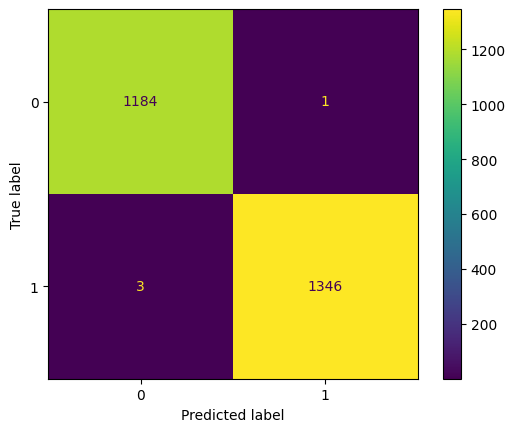

In [18]:
display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_Logistic,display_labels=[0,1])
display.plot()

## Softmax Regression Confusion Matrix

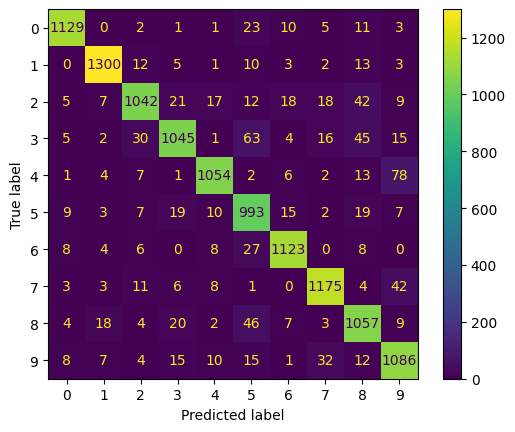

In [22]:
diplay = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_softmax)
diplay.plot()

## Neural Network Confusion Matrix

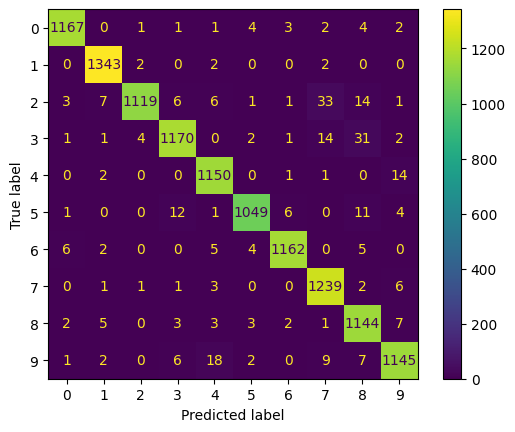

In [29]:
display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_Neural_Network)
display.plot()